In [43]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, MOUSE_IDS_TTX
from nrem_analysis.utils import load_tsg, plot_intervals

from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pynapple as nap

input_dir = RAW_DIR / "ttx"
output_dir = PROCESSED_DIR / "ttx"
SAMPLING_RATE = 20_000

### Load sleep states as IntervalSet object

Processing 116b
Dropping: 1 interval(s)
     start    end state
274  47101  47101   rem
Saving sleep states to D:\common_datasets\ucsf\processed\ttx\116b\sleep.npz
Processing 119b
Saving sleep states to D:\common_datasets\ucsf\processed\ttx\119b\sleep.npz
Processing 83b
Saving sleep states to D:\common_datasets\ucsf\processed\ttx\83b\sleep.npz
Processing 85b
Saving sleep states to D:\common_datasets\ucsf\processed\ttx\85b\sleep.npz


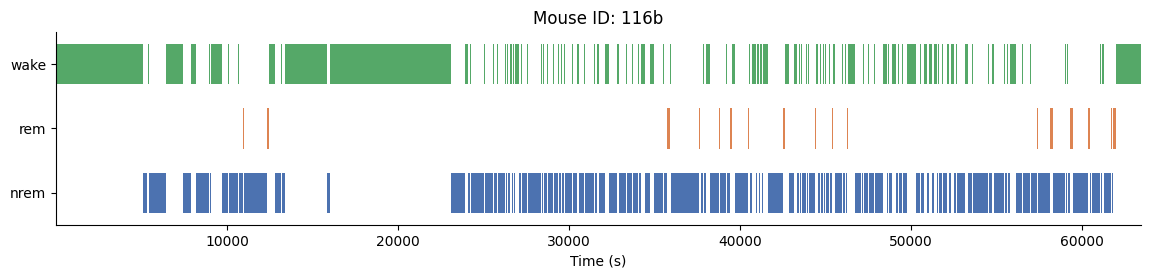

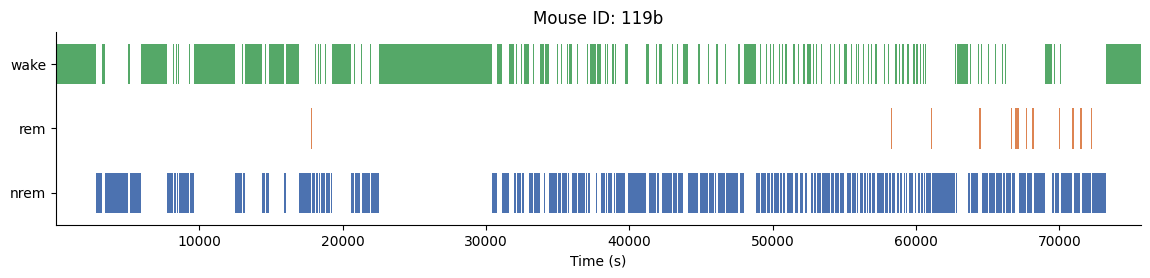

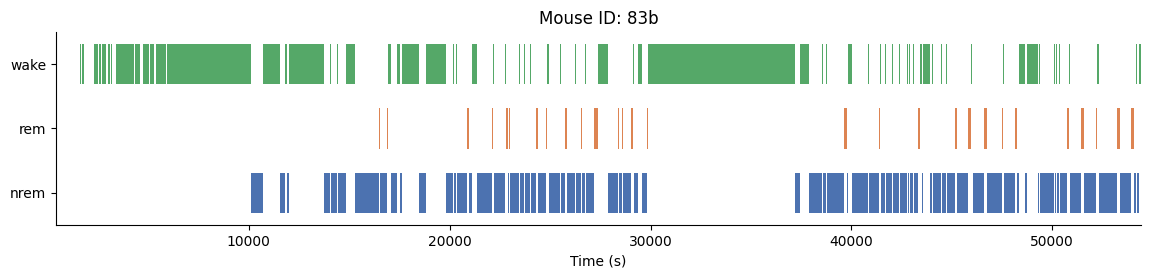

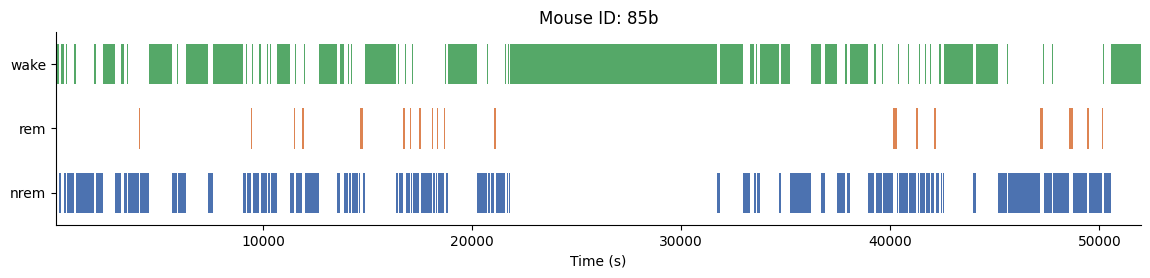

In [ ]:
states = ["wake", "nrem", "rem"]

for p in input_dir.iterdir():
    print(f"Processing {p.name}")
    df = []
    for state in states:
        data = loadmat(p / f"{state}.mat")[state].squeeze()
        df.append(pd.DataFrame(
            {
            'start': data[:,0], 
            'end': data[:,1],
            'state': state
            }))
    df = pd.concat(df).sort_values('start').reset_index(drop=True)
    idx = np.where((df['end'] - df['start']) == 0)[0]
    if len(idx) > 0:
        print(f"Dropping: {len(idx)} interval(s)")
        print(df.iloc[idx])
        df.drop(idx, inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    sleep = nap.IntervalSet(start=df['start'], end=df['end'],
                            time_units='s',
                            metadata={'state': df['state']}
                            )    
    output = output_dir / p.name / 'sleep.npz'
    output.parent.mkdir(parents=True, exist_ok=True)

    print(f"Saving sleep states to {output}")
    sleep.save(output)
    plot_intervals(sleep, column='state', title=f"Mouse ID: {p.name}")

### HD cells

In [58]:
cluster_ids

array([ 3,  4,  5, 23, 22,  6, 24,  7,  8,  9, 10,  2, 11, 14, 15, 12, 13,
       28, 25, 26, 16, 18, 17, 19, 20, 21, 27])

In [60]:
hd_uid[total:(total+len(cluster_ids))]

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1], dtype=uint8)

In [85]:
for i, mouse_id in enumerate(MOUSE_IDS_TTX):
    mouse_dir = input_dir / mouse_id
    hd_uid = loadmat(mouse_dir / "hd_uid.mat")["hd_uid"].squeeze().astype(np.bool_) # HD unit boolean mask of all shanks
    shank_paths = list(mouse_dir.glob(f'YutaTest{mouse_id}.clu.*'))
    print(f"Mouse ID: {mouse_id} (Shanks: {len(shank_paths)})")
    
    tsg_list = []
    total = 0
    print(f'--' * 50)
    # Load ADN shanks
    for i, shank_path in enumerate(shank_paths):
        print(f"Loading Shank {i + 1}")

        if mouse_id == "83b":
            load_func = np.loadtxt
        else:
            load_func = np.load

        clu = load_func(shank_path).squeeze()
        res = load_func(str(shank_path).replace("clu", "res")).squeeze()
        
        depthsort_idx = np.load(mouse_dir / f"YutaTest{mouse_id}_sortIdx_elec{i + 1}.npy")
        
        print(f"clu ({clu.shape}): {clu}")
        print(f"res ({res.shape}): {res}")
        print("--" * 50)

        clu = clu[1:] # remove the number of clusters entry
        cluster_ids = np.unique(clu).astype(int)
        cluster_ids = cluster_ids[(cluster_ids != 0) & (cluster_ids != 1)] # exclude noise and multiunit clusters
        number_of_clusters = len(cluster_ids)
        print(f"All cluster ids: {cluster_ids}")

        # Depth sort
        depthsort_idx = depthsort_idx.squeeze().astype(np.int16) - 1 # 0-indexing
        cluster_ids = cluster_ids[depthsort_idx]
        print(f"Depthsorted cluster ids: {cluster_ids}")

        shank_hd_uid = hd_uid[total:(total + number_of_clusters)]
        hd_units = cluster_ids[shank_hd_uid]

        if len(hd_units) != 0:
            tsg = load_tsg(values=res/SAMPLING_RATE, ids=clu, select_ids=hd_units)
            tsg_list.append(tsg)
        
        total += number_of_clusters        
        print(f"HD cell cluster ids: {hd_units}")
        print('--' * 50)
        print(f"Number of detected clusters in ADn Shank {i + 1}: {len(cluster_ids)}")
        print(f"Number of HD cells in ADn Shank {i + 1}: {len(hd_units)}")
        print('--' * 50)
    
    merged_tsg = nap.TsGroup.merge(*tsg_list, reset_index=True, reset_time_support=True, ignore_metadata=True)
    output = output_dir / mouse_id / "hd_units.npz"
    merged_tsg.save(output)

    print(f"Total number of units detected in ADn: {total}")
    print(f"Total HD cells: {len(merged_tsg)}")
    print('==' * 50)

Mouse ID: 83b (Shanks: 2)
----------------------------------------------------------------------------------------------------
Loading Shank 1
clu ((11291718,)): [28.  0. 18. ... 19. 28.  0.]
res ((11291717,)): [1.10000000e+02 2.27000000e+02 2.59000000e+02 ... 1.08838652e+09
 1.08838654e+09 1.08838655e+09]
----------------------------------------------------------------------------------------------------
All cluster ids: [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28]
Depthsorted cluster ids: [ 3  4  5 23 22  6 24  7  8  9 10  2 11 14 15 12 13 28 25 26 16 18 17 19
 20 21 27]
HD cell cluster ids: [ 3  5 23 22  6 24  7  8  9 10  2 11 13 25 26 16 17 20 21 27]
----------------------------------------------------------------------------------------------------
Number of detected clusters in ADn Shank 1: 27
Number of HD cells in ADn Shank 1: 20
----------------------------------------------------------------------------------------------------
Loading Sha

### Head direction

In [97]:
for mouse_id in MOUSE_IDS_TTX:
    angle = np.load(input_dir / mouse_id / f"YutaTest{mouse_id}_angle_all_1ms_OpenField.npy").squeeze()
    t = np.load(input_dir / mouse_id / f"YutaTest{mouse_id}_t_1ms_OpenField.npy").squeeze()
    hd = nap.Tsd(t, angle)
    print(f"{mouse_id} head direction data: {hd.shape}")
    hd.save(output_dir / mouse_id / "head_direction")

83b head direction data: (7547831,)
85b head direction data: (4294815,)
116b head direction data: (2109541,)
119b head direction data: (3067091,)


### Sessions

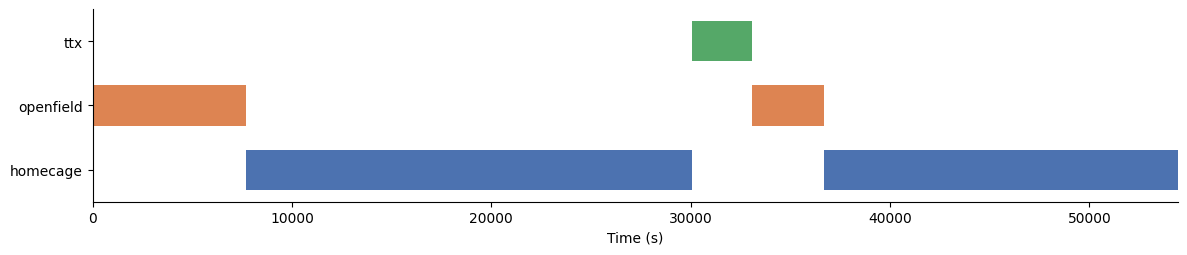

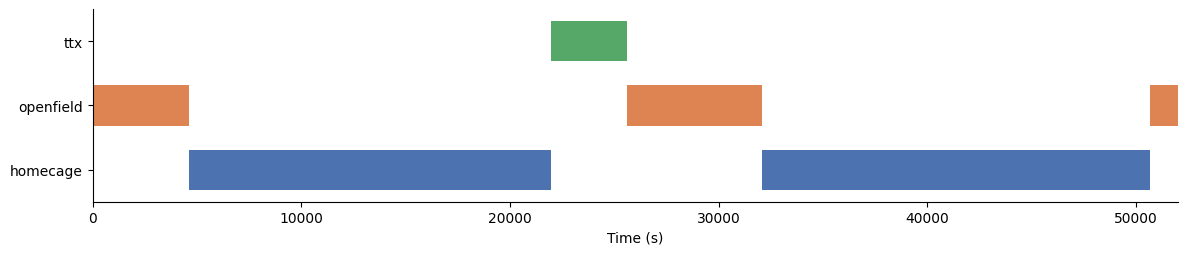

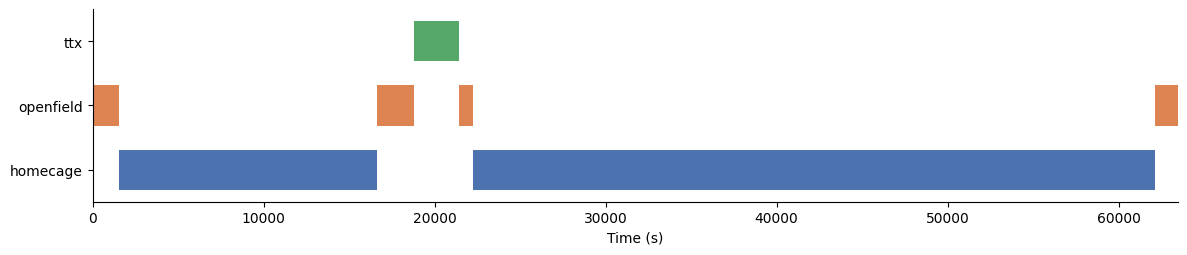

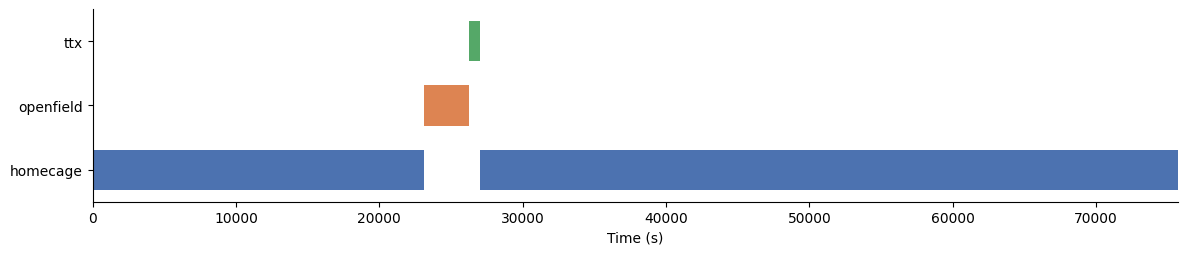

In [ ]:
for mouse_id in MOUSE_IDS_TTX:
    sessions = nap.load_file(PROCESSED_DIR / "ttx" / mouse_id / "sessions.npz")
    plot_intervals(sessions, column='label')

In [109]:
hd.time_support

  index    start      end
      0  23184.8  26251.8
shape: (1, 2), time unit: sec.

In [106]:
sessions

  index    start      end  label
      0      0    23132.6  homecage
      1  23132.6  26256.8  openfield
      2  26256.8  27029.8  ttx
      3  27029.8  75685.2  homecage
shape: (4, 2), time unit: sec.